# PRCP-1011 — Predicting Repeat Blood Donations

### Importing Libraries for Data Analysis and Visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

### Load Data

In [2]:
df= pd.read_csv('Data/Warm_Up_Predict_Blood_Donations_-_Traning_Data.csv')

In [3]:
df.head()
print("Shape:", df.shape)

Shape: (576, 6)


In [4]:
print("Shape:", df.shape)
df.head()

Shape: (576, 6)


,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Unnamed: 0                   576 non-null    int64
 1   Months since Last Donation   576 non-null    int64
 2   Number of Donations          576 non-null    int64
 3   Total Volume Donated (c.c.)  576 non-null    int64
 4   Months since First Donation  576 non-null    int64
 5   Made Donation in March 2007  576 non-null    int64
dtypes: int64(6)
memory usage: 27.1 KB


- In the data set there is one column which has no heading that's mean it is unnamed. So we can ignore that column.

In [6]:
df.describe()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,374.034722,9.439236,5.427083,1356.770833,34.050347,0.239583
std,216.947773,8.175454,5.740010,1435.002556,24.227672,0.427200
min,0.000000,0.000000,1.000000,250.000000,2.000000,0.000000
25%,183.750000,2.000000,2.000000,500.000000,16.000000,0.000000
50%,375.500000,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,562.500000,14.000000,7.000000,1750.000000,49.250000,0.000000
max,747.000000,74.000000,50.000000,12500.000000,98.000000,1.000000


In [7]:
df.isnull().sum()

Unnamed: 0                     0
Months since Last Donation     0
Number of Donations            0
Total Volume Donated (c.c.)    0
Months since First Donation    0
Made Donation in March 2007    0
dtype: int64

- There is no null values in the data set .

In [8]:
(df == -1).sum().sort_values(ascending = False)

Unnamed: 0                     0
Months since Last Donation     0
Number of Donations            0
Total Volume Donated (c.c.)    0
Months since First Donation    0
Made Donation in March 2007    0
dtype: int64

- There is no values stored as -1 . 

In [9]:
# Check duplicates after removing building_id

df.duplicated().sum()

np.int64(0)

- The dataset is clean — no missing values, no duplicate rows, no negative/invalid values. This is a well-curated dataset, but as there a column is unnamed so that column should be drop .

In [10]:
df.drop("Unnamed: 0",axis =1,inplace=True)

In [11]:
print(df.columns)

Index(['Months since Last Donation', 'Number of Donations',
       'Total Volume Donated (c.c.)', 'Months since First Donation',
       'Made Donation in March 2007'],
      dtype='str')


### Target Variable Analysis

In [12]:
target = 'Made Donation in March 2007'
counts= df[target].value_counts()

In [13]:
counts

Made Donation in March 2007
0    438
1    138
Name: count, dtype: int64

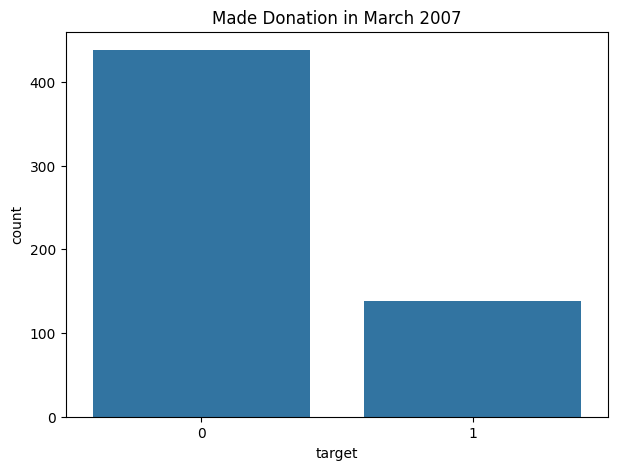

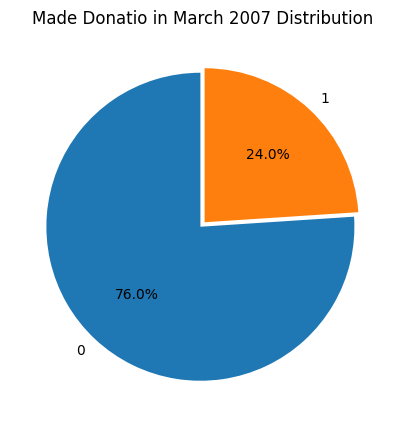

In [14]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x= target
)

plt.title("Made Donation in March 2007")
plt.xlabel("target")


plt.figure(figsize=(7,5))

plt.pie(
        x=counts,
        labels= counts.index,
        autopct='%1.1f%%',
        startangle=90,
        explode=[0.02, 0.02]
)

plt.title('Made Donatio in March 2007 Distribution')

plt.show()

Made Donation in March 2007 :
    0 -->   76.041667 ; 1 -->   23.958333

- Class Imbalance: Only ~24% of donors donated again in March 2007 and 76% did not . This is a moderately imbalanced binary classification problem. So we must evaluate with ROC-AUC, Recall, Precision and F1, and consider class-imbalance handling (SMOTE) during modeling.

#### Univariate Analysis

In [15]:
features = [ 'Months since Last Donation', 'Number of Donations',
       'Total Volume Donated (c.c.)', 'Months since First Donation'
           ]

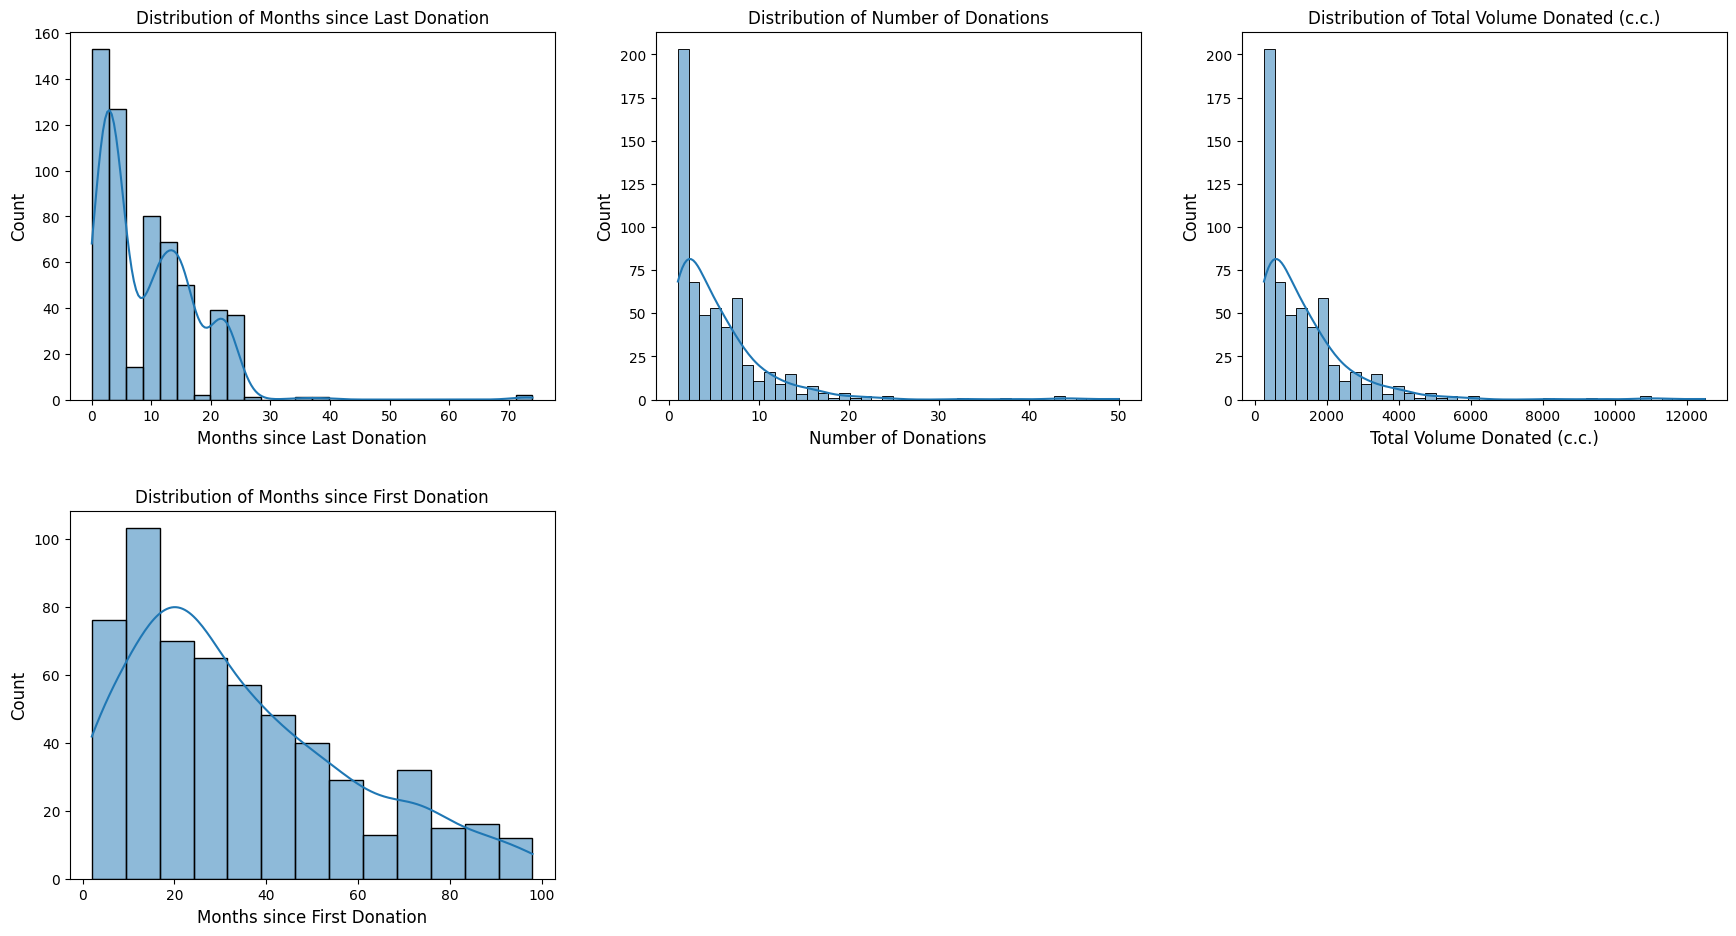

In [16]:
plt.figure(figsize=(18,10),facecolor ='white')

plotnumber =1

for column in features:
    ax=plt.subplot(2,3,plotnumber)
    
    sns.histplot(
        data=df,
        x=column,
        kde= True,
    )

    plt.title(f'Distribution of {column}')
    plt.xlabel(column, fontsize = 12)
    plt.ylabel('Count', fontsize = 12)

    plotnumber +=1

plt.tight_layout(pad = 3.0)

plt.show()

- All four features are `right-skewed` with a large majority of one-time .
- `Total Volume` and `Number of Donations` are essentially duplicate signals means `perfectly correlated`, so you likely only need one of them in modeling to      avoid redundancy.


#### Box Plot — Outlier Detection

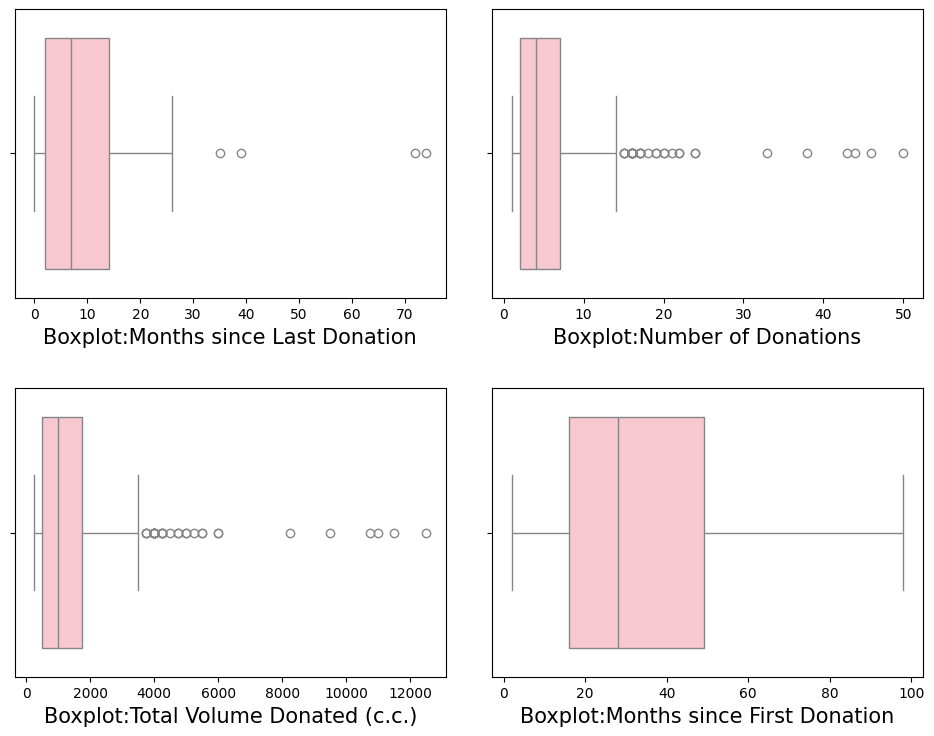

In [17]:
plt.figure(figsize=(10,8), facecolor= 'white')

plotnumber =1

for column in features:
    ax=plt.subplot(2,2,plotnumber)
    
    sns.boxplot(
    data =df,
    x= column,
    color='pink'
    )

    plt.xlabel(f'Boxplot:{column}', fontsize = 15)
    plt.ylabel("")

    plotnumber +=1

plt.tight_layout(pad =3.0)
plt.show()
    

- The first three variables are all tightly clustered with long right-tail outliers       (typical donor behavior — most give rarely, a few give a lot).
- `Months since First Donation` behaves completely differently — it's naturally spread     out with no outliers, since every donor has a distinct signup history.
- `Months since First Donation` this variable is likely a more stable/normal feature       for modeling compared to the other three, which are skewed and outlier-heavy.

### Bivariate Analysis

#### Features VS Target Variable

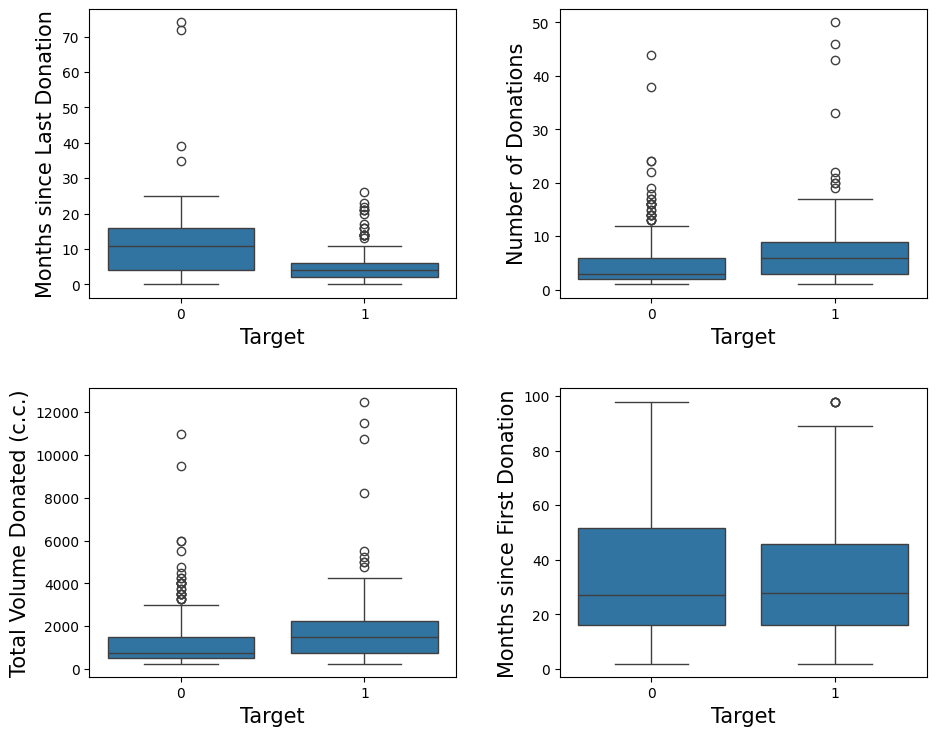

In [18]:
plt.figure(figsize=(10,8), facecolor ='white')
plotnumber =1

for column in features:
    ax= plt.subplot(2,2,plotnumber)

    sns.boxplot(
        data =df,
        x = target,
        y = column
    )

    plt.xlabel('Target', fontsize= 15)
    plt.ylabel(column, fontsize =15)

    plotnumber +=1

plt.tight_layout(pad =3.0)
plt.show()


- `Months since Last Donation` and `Number of Donations` and `Total Volume` show           meaningful separation between classes — good candidate features for a model.

- `Months since First Donation` shows almost no separation — consider it lower priority to drop it, or check its correlation with other features.

#### Correlation Heatmap

In [19]:
df.columns

Index(['Months since Last Donation', 'Number of Donations',
       'Total Volume Donated (c.c.)', 'Months since First Donation',
       'Made Donation in March 2007'],
      dtype='str')

In [20]:
df.corr()

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
Months since Last Donation,1.000000,-0.159731,-0.159731,0.186899,-0.261234
Number of Donations,-0.159731,1.000000,1.000000,0.622116,0.220615
Total Volume Donated (c.c.),-0.159731,1.000000,1.000000,0.622116,0.220615
Months since First Donation,0.186899,0.622116,0.622116,1.000000,-0.019819
Made Donation in March 2007,-0.261234,0.220615,0.220615,-0.019819,1.000000


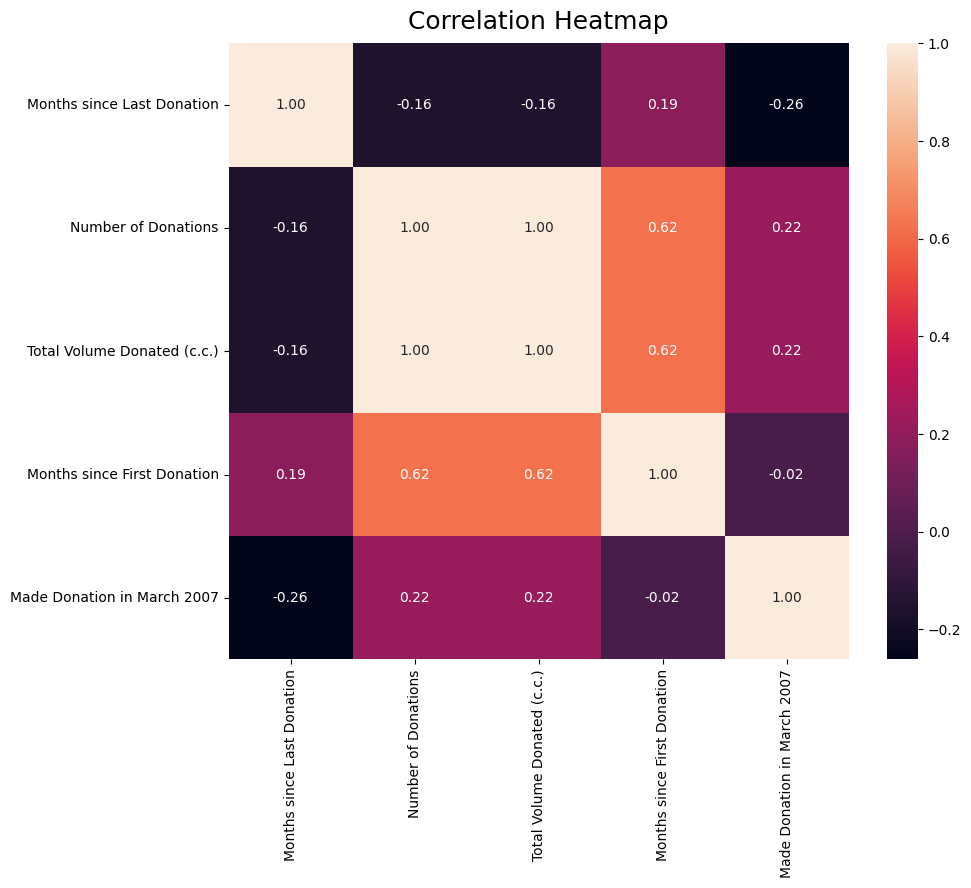

In [21]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot= True,
    fmt=".2f",
)

plt.title("Correlation Heatmap",  fontsize = 18 , y=1.01)
plt.show()

- Since `Number of Donations` and `Total Volume Donated` are perfectly correlated (r = 1.00), keeping both would introduce `multicollinearity` and negatively affect the model. So I will drop `Total Volume Donated` and keep `Number of Donations` for further steps.

- `Months since Last Donation` is negatively correlated with the target, while            `Number of Donations` is positively correlated (frequent past donors are more likely     to return).


In [22]:
data=df.drop('Total Volume Donated (c.c.)',axis= 1, inplace = True)

### Defining Feature and Target Variable

In [23]:
X= df.drop([target],axis=1)
Y=df[target]

In [24]:
print("Feature Set:", X.columns.tolist())
print("X Shape:", X.shape, "Y Shape:", Y.shape)

Feature Set: ['Months since Last Donation', 'Number of Donations', 'Months since First Donation']
X Shape: (576, 3) Y Shape: (576,)


### Importing Libraries for Preprocessing 

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split


#### Train - Test Split

In [26]:
X_Train,X_Test, Y_Train,Y_Test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

### Importing Libraries for Models

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier


###  Creating Multiple Pipelines for Multiple Models

In [29]:
lr_pipeline = Pipeline(steps=[
    
    ("classifier", LogisticRegression())

])

In [30]:
Kn_pipeline = Pipeline(steps=[
    
    ("classifier" , KNeighborsClassifier())

])

In [31]:
dt_pipeline = Pipeline(steps=[

    ("classifier", DecisionTreeClassifier())

])

In [32]:
rf_pipeline = Pipeline(steps=[

    ("classifier", RandomForestClassifier())

])

In [33]:
gb_pipeline = Pipeline(steps=[

    ("classifier", GradientBoostingClassifier())

])

In [34]:
xgb_pipeline = Pipeline(steps=[

    ("classifier", XGBClassifier())
])

In [42]:
# Storing all the Model names and Model_pipeline for better structured training and evaluation of the Models
models = {

    "Logistic Regression": lr_pipeline,

    "K-Nearest Neighbors": Kn_pipeline,
    
    "Decission Tree": dt_pipeline,
    
    "Random Forest": rf_pipeline,

    "Gradient Boosting": gb_pipeline,

    "XGBoost": xgb_pipeline

}

## Training and Evaluating the Models

In [43]:
# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

In [55]:
results = []

for name, model in models.items():

    # Train
    model.fit(X_Train, Y_Train)

    # Predict
    Y_pred = model.predict(X_Test)

    # Metrics
    accuracy = accuracy_score(
        Y_Test, 
        Y_pred,
    )

    precision = precision_score(        
        Y_Test, 
        Y_pred,
        average='weighted'
    )

    recall = recall_score(
        Y_Test, 
        Y_pred,
        average='weighted'
    )

    f1 = f1_score(
        Y_Test, 
        Y_pred,
        average='weighted'
    )

    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

print(results_df.to_string(col_space=20))  # for spacing between the columns

                                    Model             Accuracy            Precision               Recall             F1 Score
0                     Logistic Regression             0.750000             0.690789             0.750000             0.657920
1                     K-Nearest Neighbors             0.784483             0.770068             0.784483             0.773860
2                          Decission Tree             0.672414             0.679886             0.672414             0.675969
3                           Random Forest             0.706897             0.693407             0.706897             0.699334
4                       Gradient Boosting             0.741379             0.724404             0.741379             0.730769
5                                 XGBoost             0.732759             0.742188             0.732759             0.736986


- Best overall: K-Nearest Neighbors. It's highest on all four metrics (accuracy 0.784, F1 0.774).
- Worst: Decision Tree (accuracy 0.664). It's likely overfitting, and the ensembles (Random Forest, Gradient Boosting, XGBoost) improve on it as               expected.
- Random Forest, Gradient Boosting and XGBoost are close (F1 ~0.73-0.74). XGBoost has the best precision and F1 of the three.
- Logistic Regression looks misleading. Its accuracy is 0.75, but its F1 (0.658) is the lowest apart from the Decision Tree, and precision is only      0.69. It is probably predicting mostly the majority class (Target=0).

## Comparing Cross Validation Score for the Models

In [59]:
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():

    f1_scores = cross_val_score(
        model,
        X_Train,
        Y_Train,
        cv=10,
        scoring='f1_weighted',
        n_jobs=-1
    )

    auc_scores = cross_val_score(
        model,
        X_Train,
        Y_Train,
        cv=10,
        scoring='roc_auc',
        n_jobs=-1
    )
    
    cv_results.append({

        "Model": name,

        "CV Mean F1 Weighted": f1_scores.mean(),
        "CV F1 Std " : f1_scores.std(),
        
        "CV Mean ROC AUC" : auc_scores.mean(),
        "CV AUC Std": auc_scores.std()

    })

cv_results_df = pd.DataFrame(cv_results)

print(cv_results_df.to_string(col_space=20))  # for spacing between the columns)

                                    Model  CV Mean F1 Weighted           CV F1 Std       CV Mean ROC AUC           CV AUC Std
0                     Logistic Regression             0.703579             0.049921             0.739370             0.101927
1                     K-Nearest Neighbors             0.749091             0.053360             0.624039             0.087374
2                          Decission Tree             0.673937             0.053776             0.564401             0.087466
3                           Random Forest             0.736330             0.060801             0.648137             0.065969
4                       Gradient Boosting             0.722195             0.057196             0.660381             0.086753
5                                 XGBoost             0.738542             0.055495             0.627935             0.073427


1. `Logistic Regression` has the best ROC-AUC (0.739), well ahead of the rest. AUC measures how well the model ranks donors vs non-donors, and there      it wins clearly.
2. `KNN` has the best weighted F1 but a low AUC (0.624).
3. `Decision Tree` is the weakest on both metrics (AUC 0.564 is barely above random at 0.5), consistent with overfitting.
4. `Random Forest`, `Gradient Boosting` and `XGBoost` are mid-pack, with AUC around 0.63-0.66. They should improve with tuning.
5. The std is large (0.07-0.10 on AUC), so gaps of 0.02-0.03 between models aren't meaningful. Logistic Regression's lead over the others is more        convincing, but still not certain.

##### Based on 10-fold cross-validation, I selected Logistic Regression, K-Nearest Neighbors, Random Forest, and XGBoost for hyperparameter tuning. Logistic Regression achieved the highest ROC-AUC (0.739), while KNN, Random Forest, and XGBoost achieved the highest weighted F1 scores (0.749, 0.736, and 0.739). Decision Tree was excluded because it performed worst on both metrics, and Gradient Boosting was excluded because it is similar to XGBoost.

## Hyperparameter Tuning

#### Logistic Regression

In [62]:
from sklearn.model_selection import RandomizedSearchCV

lr_params = {
    
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    
    'classifier__solver': ['liblinear', 'lbfgs'],
    
    'classifier__class_weight': [None, 'balanced'],
    
    'classifier__max_iter': [1000, 2000]
    
}

lr_random_search = RandomizedSearchCV(
    
    estimator=lr_pipeline,
    
    param_distributions=lr_params,
    
    n_iter=20,
    
    cv=5,
    
    scoring='roc_auc',
    
    verbose=1,
    
    random_state=42,
    
    n_jobs=-1
    
)

# Train Logistic Regression Tuning
lr_random_search.fit(X_Train, Y_Train)

# Best Parameters
print("Best Logistic Regression Parameters:")
print(lr_random_search.best_params_)

# Best CV Score
print("\nBest Logistic Regression CV ROC-AUC:")
print(lr_random_search.best_score_)

# Best Model
best_lr_model = lr_random_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Logistic Regression Parameters:
{'classifier__solver': 'lbfgs', 'classifier__max_iter': 1000, 'classifier__class_weight': 'balanced', 'classifier__C': 10}

Best Logistic Regression CV ROC-AUC:
0.7408484238765929


##### Previously 10-fold CV showed that Logistic Regression had the strongest ROC-AUC. So we're allowing tuning to optimize the metric that already showed strength for this model.

#### KNN

In [64]:
knn_params = {
    
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    
    'classifier__weights': ['uniform', 'distance'],
    
    'classifier__metric': ['euclidean', 'manhattan', 'minkowski'],
    
    'classifier__p': [1, 2]
    
}

knn_random_search = RandomizedSearchCV(
    
    estimator=Kn_pipeline,
    
    param_distributions=knn_params,
    
    n_iter=20,
    
    cv=5,
    
    scoring='roc_auc',
    
    verbose=1,
    
    random_state=42,
    
    n_jobs=-1
    
)

# Train KNN Tuning
knn_random_search.fit(X_Train, Y_Train)

# Best Parameters
print("Best KNN Parameters:")
print(knn_random_search.best_params_)

# Best CV Score
print("\nBest KNN CV Weighted F1:")
print(knn_random_search.best_score_)

# Best Model
best_knn_model = knn_random_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best KNN Parameters:
{'classifier__weights': 'uniform', 'classifier__p': 2, 'classifier__n_neighbors': 21, 'classifier__metric': 'manhattan'}

Best KNN CV Weighted F1:
0.6810075605146028


#### Random Forest

In [67]:
rf_params = {

    'classifier__n_estimators': [100, 200],

    'classifier__max_depth': [10, 20, 30, None],

    'classifier__min_samples_split': [2, 5, 10],

    'classifier__min_samples_leaf': [1, 2, 4],

    'classifier__max_features': ['sqrt', 'log2']

}

rf_random_search = RandomizedSearchCV(

    estimator=rf_pipeline,

    param_distributions=rf_params,

    n_iter=10,

    cv=3,

    scoring='roc_auc',

    verbose=2,

    random_state=42,

    n_jobs=-1

)

# Train Random Forest Tuning
rf_random_search.fit(X_Train, Y_Train)

# Best Parameters
print("Best Random Forest Parameters:")
print(rf_random_search.best_params_)

# Best Score
print("\nBest Random Forest CV Score:")
print(rf_random_search.best_score_)

# Best Model
best_rf_model = rf_random_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Random Forest Parameters:
{'classifier__n_estimators': 100, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 10}

Best Random Forest CV Score:
0.6938787077675967


#### XGB

In [66]:
xgb_params = {

    'classifier__n_estimators': [100, 200],

    'classifier__max_depth': [3, 5, 7],

    'classifier__learning_rate': [0.01, 0.05, 0.1],

    'classifier__subsample': [0.8, 1.0],

    'classifier__colsample_bytree': [0.8, 1.0]

}

xgb_random_search = RandomizedSearchCV(

    estimator=xgb_pipeline,

    param_distributions=xgb_params,

    n_iter=10,

    cv=3,

    scoring='roc_auc',

    verbose=2,

    random_state=42,

    n_jobs=-1

)

# Train XGBoost Tuning
xgb_random_search.fit(X_Train, Y_Train)

# Best Parameters
print("Best XGBoost Parameters:")
print(xgb_random_search.best_params_)

# Best Score
print("\nBest XGBoost CV Score:")
print(xgb_random_search.best_score_)

# Best Model
best_xgb_model = xgb_random_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost Parameters:
{'classifier__subsample': 0.8, 'classifier__n_estimators': 100, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.8}

Best XGBoost CV Score:
0.7084969584969585


So with ROC-AUC for all four:

|    Model	                |  Tuned ROC-AUC	|    Untuned         |     
|---------------------------|-------------------|--------------------|
|    Logistic Regression	|       0.741   	|        0.739       |
|         XGBoost	        |       0.708	    |        0.628       |
|      Random Forest	    |       0.693	    |        0.648       |
|         KNN	            |       0.681	    |        0.624       |

1. `Logistic Regression` is the best and barely changed with tuning, so it was already a good fit.
2. `XGBoost`, `Random Forest` and `KNN` improved a lot with tuning, but still sit below Logistic Regression.
3. The data looks mostly linear and simple, so a regularized linear model does well and complex models don't add much.

**So among those `Logistic Regression` as the final model, predict on the test set once, and then do the confusion matrix, classification report.**

## Confusion Matrix

In [71]:
final_pred = best_lr_model.predict(X_Test)

<Figure size 800x600 with 0 Axes>

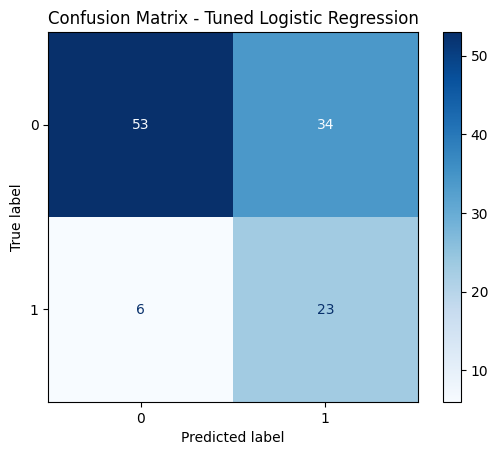

In [73]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8,6))

ConfusionMatrixDisplay.from_predictions(
    Y_Test,
    final_pred,
    cmap='Blues'
)

plt.title('Confusion Matrix - Tuned Logistic Regression')

plt.show()

**The model looked at 116 people and made a guess for each one: "will donate" or "won't donate".**

**The 4 boxes:**

53: The model said "won't donate", and it was right.
23: The model said "will donate", and it was right.
6: The model said "won't donate", but the person did donate. The model missed them.
34: The model said "will donate", but the person didn't. This is a false alarm.

Total correct = 53 + 23 = 76 out of 116 (about 65%).

It means out of 29 real donors, the model found 23. That's good.


## Classification Report

              precision    recall  f1-score   support

           0       0.90      0.61      0.73        87
           1       0.40      0.79      0.53        29

    accuracy                           0.66       116
   macro avg       0.65      0.70      0.63       116
weighted avg       0.77      0.66      0.68       116

Test ROC-AUC: 0.7877526753864447


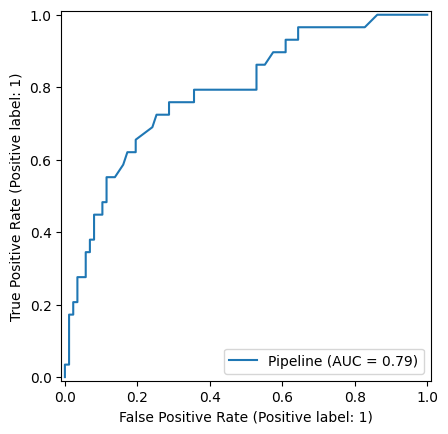

In [75]:
from sklearn.metrics import classification_report

print(classification_report(Y_Test, final_pred))

final_prob = best_lr_model.predict_proba(X_Test)[:, 1]
print("Test ROC-AUC:", roc_auc_score(Y_Test, final_prob))

RocCurveDisplay.from_estimator(best_lr_model, X_Test, Y_Test)
plt.show()

**The tuned Logistic Regression achieved a test ROC-AUC of 0.79 and identified 79% of donors (recall), with a precision of 0.40, showing a trade-off toward catching donors on an imbalanced dataset.**

### Report on Challenges Faced

| Challenge | Why it's a problem | Technique used | Reason |
|---|---|---|---|
| **Perfect multicollinearity** between `Number of Donations` and `Total Volume Donated (c.c.)` (r = 1.00, since Volume = 250 × Donations) | Destabilizes linear-model coefficients (infinite VIF); inflates apparent feature importance in tree models without adding information | Dropped `Total Volume Donated (c.c.)`, kept `Number of Donations` | Removing a perfectly redundant feature has zero information cost and improves model stability/interpretability |
| **Class imbalance** (~76% No vs ~24% Yes) | Accuracy is misleading; naive models can score ~76% by always predicting "No", ignoring the minority class the business actually cares about | Used `class_weight='balanced'` in each classifier; benchmarked against SMOTE oversampling inside the CV pipeline; ranked models by **ROC-AUC/Recall/F1**, not accuracy | Class weighting/resampling forces the model to pay attention to the minority (positive) class; AUC-type metrics are threshold- and imbalance-robust |
| **Small dataset** (576 rows, ~460 for training) | High risk of overfitting for flexible models (KNN, deep trees, SVM); unstable single train/test split estimates | Used **5-fold Stratified Cross-Validation** for model selection and tuning rather than a single split; kept a held-out test set only for final, one-time evaluation | Cross-validation averages performance over multiple folds, giving a much more reliable estimate of generalization on limited data |
| **Right-skewed features** with outliers (e.g., a few donors with 40–50 donations) | Can distort distance-based models (KNN, SVM) and linear-model coefficient scale | Applied `StandardScaler` inside the pipeline (fit only on training folds); deliberately **kept** outliers rather than removing them | These are legitimate loyal-donor records, not data errors — removing them would throw away exactly the "frequent past donor" signal that predicts return donations |
| **Choosing a single "best" metric among many** (Accuracy/Precision/Recall/F1/ROC-AUC often disagree) | Optimizing for the wrong metric can produce a model that looks good on paper but fails the real business objective | Selected **ROC-AUC** as the primary ranking metric (threshold-independent, imbalance-robust) while explicitly reporting Recall/F1/Precision alongside it, and discussing the threshold trade-off for deployment | Gives a holistic, business-aware view rather than optimizing a single number in isolation |


### Conclusions


- Goal: Predict whether a donor will donate again (Made Donation in March 2007).
- Key findings: Recent donors (low Months since Last Donation) and frequent donors (high Number of Donations) were most likely to donate again. Total - Volume was dropped (r = 1.00 with Number of Donations), and Months since First Donation had almost no link to the target.
- Best model: Tuned Logistic Regression (CV ROC-AUC 0.74).
- Test results: ROC-AUC 0.79, donor recall 0.79, donor precision 0.40, accuracy 0.66.
- Trade-off: It finds most real donors but makes many false alarms, which is acceptable if missing a donor costs more.
- Limitations: Small dataset (only 29 donors in the test set), so results may shift with a different split.
